<a href="https://colab.research.google.com/github/algaebrown/RBPNet/blob/main/rbpnet_colab_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U "huggingface_hub[cli]"
!pip install pytorch-lightning
!pip install tqdm
!hf download yeolab/eCLIP \
    --repo-type dataset \
    --include "RBFOX2_HepG2_ENCSR987FTF/**" \
    --local-dir eCLIP
!git clone https://github.com/algaebrown/RBPNet.git

/bin/bash: line 1: pip: command not found
/bin/bash: line 1: pip: command not found
/bin/bash: line 1: pip: command not found
Reconstructing (incomplete total...): |           |  0.00B /  0.00B            

Fetching 5 files:   0%|                                  | 0/5 [00:00<?, ?it/s]

Fetching 5 files: 100%|██████████████████████████| 5/5 [00:00<00:00, 23.14it/s]
Download complete: :                                       |  0.00B            
Reconstruction complete: |                        |  0.00B /  0.00B            ✓ Downloaded
  path: /home/charl/RBPNet/eCLIP
Download complete: :                                       |  0.00B            
Reconstruction complete: |                        |  0.00B /  0.00B            
Cloning into 'RBPNet'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 43 (delta 18), reused 28 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (43/43), 9

In [2]:
from datasets import load_dataset
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

import sys
sys.path.append("RBPNet")
from RBPNet import RBPNet
### Module ###
from module import Module
from losses import rbpnet_loss
from metrics import rbpnet_metrics, dlog_odds_from_data, pearson_corr

# Set-up callbacks
from genericpath import exists
# Logger
import os
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks.lr_monitor import LearningRateMonitor
from pytorch_lightning import Trainer

# plot training curve
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr
from tqdm import tqdm

# --- Custom Implementations replacing seqpro ---
def custom_ohe(seq, alphabet="ACGT"):
    """One-hot encodes a single sequence string or array of characters."""
    char_to_idx = {char: idx for idx, char in enumerate(alphabet)}
    # Handle 0-d numpy arrays containing strings
    if isinstance(seq, np.ndarray) and seq.ndim == 0:
        seq = str(seq.item())
    chars = np.array(list(seq) if isinstance(seq, str) else [str(c) for c in seq])
    seq_encoded = np.zeros((len(chars), len(alphabet)), dtype=np.float32)
    for i, char in enumerate(chars):
        if char in char_to_idx:
            seq_encoded[i, char_to_idx[char]] = 1.0
    return seq_encoded

def apply_jitter_single(seq, control, signal, max_jitter, seed=None):
    """Applies jitter to a single example's arrays."""
    if max_jitter <= 0:
        return seq, control, signal
        
    rng = np.random.default_rng(seed)
    
    # Calculate the new length
    original_length = seq.shape[-1]
    jittered_length = original_length - 2 * max_jitter
    
    if jittered_length <= 0:
        raise ValueError(f"Array length {original_length} is too small for max_jitter {max_jitter}")
    
    # Generate a single start index between 0 and 2*max_jitter
    start_idx = rng.integers(0, 2 * max_jitter + 1)
    end_idx = start_idx + jittered_length
    
    # Slice arrays (assuming length is the last dimension)
    jittered_seq = seq[..., start_idx:end_idx]
    jittered_control = control[..., start_idx:end_idx]
    jittered_signal = signal[..., start_idx:end_idx]
    
    return jittered_seq, jittered_control, jittered_signal
# ------------------------------------------------


/home/charl/RBPNet/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
ds = load_dataset(
    "yeolab/eCLIP",
    name="RBFOX2_HepG2_ENCSR987FTF",
)

In [4]:

class ECLIPDataset(Dataset):
    def __init__(self, hf_dataset, max_jitter=0, seed=None):
        self.ds = hf_dataset
        self.max_jitter = max_jitter
        self.seed = seed

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        ex = self.ds[idx]

        seq = np.char.upper(ex["seq"])
        # Use custom OHE
        seq = custom_ohe(seq, "ACGT").swapaxes(0, 1)

        control = np.asarray(ex["control"], dtype=np.float32)
        signal = np.asarray(ex["signal"], dtype=np.float32)

        # Apply jitter if configured (Training)
        if self.max_jitter > 0:
            # Incorporate index into seed for randomness across items but determinism for same item
            item_seed = self.seed + idx if self.seed is not None else None
            seq, control, signal = apply_jitter_single(seq, control, signal, self.max_jitter, item_seed)
        else:
            # If no jitter (Validation/Test), we MUST statically trim by 32 
            # so the input length matches the jittered training data length
            seq = seq[..., 32:-32]
            control = control[..., 32:-32]
            signal = signal[..., 32:-32]

        return {
            "seq": torch.from_numpy(seq).float(),
            "control": torch.from_numpy(control).float(),
            "signal": torch.from_numpy(signal).float(),
            "gc_fraction": torch.tensor(ex["gc_fraction"], dtype=torch.float32),
            "n_IN": torch.tensor(ex["n_IN"], dtype=torch.float32),
            "n_IP": torch.tensor(ex["n_IP"], dtype=torch.float32),
        }


In [5]:
# Use jittering only for the training set (max_jitter=32 to match train.py)
train_dataset = ECLIPDataset(ds["train"], max_jitter=32)

train_dl = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    drop_last=True,
    num_workers=4,
)

# No jitter for validation, but ECLIPDataset will now statically trim by 32
valid_dataset = ECLIPDataset(ds["validation"], max_jitter=0)
valid_dl = DataLoader(
    valid_dataset,
    batch_size=256,  # Matched to train.py
    shuffle=False,   # Matched to train.py
    drop_last=False,
    num_workers=4,
)

# No jitter for testing, statically trims by 32
test_dataset = ECLIPDataset(ds["test"], max_jitter=0)
test_dl = DataLoader(
    test_dataset,
    batch_size=1024,
    shuffle=False,  # Usually test shouldn't be shuffled
    drop_last=False,
    num_workers=4,
)


In [6]:
for dset in ['test', 'train', 'validation']:
  chroms = ds[dset].unique("chrom")
  print(dset, ':', chroms)

test : ['chr2', 'chr9', 'chr16']
train : ['chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr17', 'chr18', 'chr19', 'chr20', 'chr21', 'chr22']
validation : ['chr1', 'chr8', 'chr15']


In [7]:
# architecture

mask = 100
arch = RBPNet(mask = mask)

In [8]:

# LightningModule
module = Module(
    arch=arch,
    input_variables=["seq"],
    output_variables=["eCLIP_profile", "signal_profile", "control_profile", "mixing_coefficient",
                    "d_log_odds"],
    target_variables=["signal", "control", "gc_fraction", "n_IN", "n_IP"],
    loss_fxn=rbpnet_loss,
    metrics_fxn=rbpnet_metrics
)


In [9]:

log_dir = './log'
if not exists(log_dir):
    os.makedirs(log_dir)

logger = CSVLogger(save_dir=log_dir, name="", version="")


callbacks = []
model_checkpoint_callback = ModelCheckpoint(
    dirpath=os.path.join(
        logger.save_dir,
        logger.name,
        logger.version,
        "checkpoints"
    ),
    save_top_k=5,
    monitor="val_loss_epoch",
)
callbacks.append(model_checkpoint_callback)
early_stopping_callback = EarlyStopping(
    monitor="val_loss_epoch",
    patience=10,
    mode="min",
    verbose=True,
    #check_on_train_epoch_end=False ###https://github.com/Lightning-AI/pytorch-lightning/issues/9151
)
callbacks.append(early_stopping_callback)
callbacks.append(LearningRateMonitor())
callbacks



In [10]:
# Trainer

trainer = Trainer(
    max_epochs=100, # Matched to train.py
    logger=logger,
    devices="auto",
    accelerator="auto",
    callbacks=callbacks,
    num_sanity_val_steps=2
)

# Fit
trainer.fit(
    module,
    train_dataloaders=train_dl,
    val_dataloaders=valid_dl,
)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name | Type   | Params | Mode  | FLOPs
------------------------------------------------
0 | arch | RBPNet | 899 K  | train | 0    
------------------------------------------------
899 K     Trainable params
0         Non-trainable params
899 K     Total params
3.599     Total estimated model params size (MB)
59        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/charl/RBPNet/.venv/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 10: 100%|██████████| 1662/1662 [01:47<00:00, 15.48it/s, train_loss=1.09e+3, val_loss_epoch=1.33e+3, val_eCLIP_loss_epoch=592.0, val_control_loss_epoch=439.0, val_binom_loss_epoch=154.0, val_eCLIP_profile_pearson_epoch=0.581, val_control_profile_pearson_epoch=0.351, val_d_log_odds_profile_pearson_epoch=0.493, val_pi_pearson_epoch=0.556]{'val_loss_epoch': tensor(1337.9058, device='cuda:0'), 'val_eCLIP_loss_epoch': tensor(794.4438, device='cuda:0'), 'val_control_loss_epoch': tensor(418.7263, device='cuda:0'), 'val_binom_loss_epoch': tensor(60.6496, device='cuda:0'), 'val_eCLIP_profile_pearson_epoch': tensor(0.4877, device='cuda:0'), 'val_control_profile_pearson_epoch': tensor(0.2266, device='cuda:0'), 'val_d_log_odds_profile_pearson_epoch': tensor(0.3980, device='cuda:0'), 'val_pi_pearson_epoch': tensor(0.4831, device='cuda:0')}
{'val_loss_epoch': tensor(1238.5642, device='cuda:0'), 'val_eCLIP_loss_epoch': tensor(814.3357, device='cuda:0'), 'val_control_loss_epoch': tensor(318.4246,

Metric val_loss_epoch improved by 5.006 >= min_delta = 0.0. New best score: 1327.512


Epoch 13: 100%|██████████| 1662/1662 [01:46<00:00, 15.54it/s, train_loss=1.2e+3, val_loss_epoch=1.33e+3, val_eCLIP_loss_epoch=587.0, val_control_loss_epoch=443.0, val_binom_loss_epoch=152.0, val_eCLIP_profile_pearson_epoch=0.584, val_control_profile_pearson_epoch=0.362, val_d_log_odds_profile_pearson_epoch=0.476, val_pi_pearson_epoch=0.545] {'val_loss_epoch': tensor(1329.4126, device='cuda:0'), 'val_eCLIP_loss_epoch': tensor(787.4490, device='cuda:0'), 'val_control_loss_epoch': tensor(411.0769, device='cuda:0'), 'val_binom_loss_epoch': tensor(62.6527, device='cuda:0'), 'val_eCLIP_profile_pearson_epoch': tensor(0.5043, device='cuda:0'), 'val_control_profile_pearson_epoch': tensor(0.2550, device='cuda:0'), 'val_d_log_odds_profile_pearson_epoch': tensor(0.3304, device='cuda:0'), 'val_pi_pearson_epoch': tensor(0.4022, device='cuda:0')}
{'val_loss_epoch': tensor(1262.6482, device='cuda:0'), 'val_eCLIP_loss_epoch': tensor(839.3328, device='cuda:0'), 'val_control_loss_epoch': tensor(318.5351,

Monitored metric val_loss_epoch did not improve in the last 10 records. Best score: 1327.512. Signaling Trainer to stop.


Epoch 22: 100%|██████████| 1662/1662 [02:23<00:00, 11.61it/s, train_loss=1.05e+3, val_loss_epoch=1.34e+3, val_eCLIP_loss_epoch=585.0, val_control_loss_epoch=458.0, val_binom_loss_epoch=148.0, val_eCLIP_profile_pearson_epoch=0.587, val_control_profile_pearson_epoch=0.366, val_d_log_odds_profile_pearson_epoch=0.451, val_pi_pearson_epoch=0.517]



/tmp/ipykernel_88263/3055548148.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


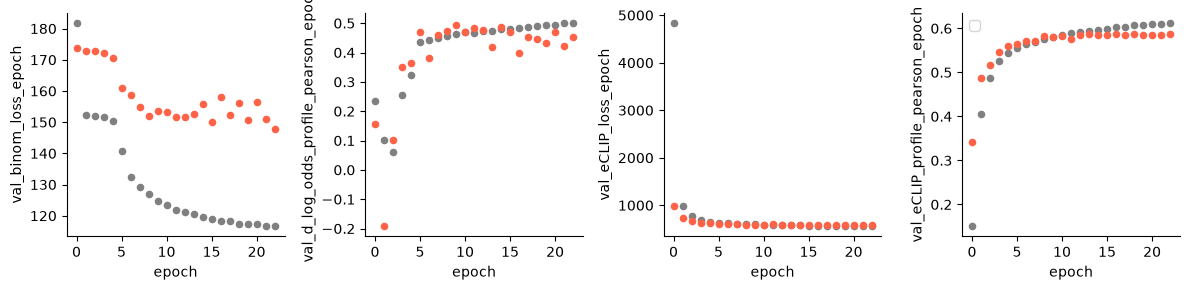

In [11]:

f, axes = plt.subplots(1,4,figsize = (12,3))
metric_df = pd.read_csv(Path(log_dir) / 'metrics.csv')
metric_df.plot.scatter(x = 'epoch', y = 'train_binom_loss_epoch',
                    ax = axes[0], color = 'grey')
metric_df.plot.scatter(x = 'epoch', y = 'val_binom_loss_epoch',
                    ax = axes[0], color = 'tomato')

metric_df.plot.scatter(x = 'epoch',
                    y = 'train_d_log_odds_profile_pearson_epoch',
                    ax = axes[1], color = 'grey')
metric_df.plot.scatter(x = 'epoch',
                    y = 'val_d_log_odds_profile_pearson_epoch',
                    ax = axes[1], color = 'tomato')

metric_df.plot.scatter(x = 'epoch', y = 'train_eCLIP_loss_epoch',
                    ax = axes[2], color = 'grey')
metric_df.plot.scatter(x = 'epoch', y = 'val_eCLIP_loss_epoch',
                    ax = axes[2], color = 'tomato')

metric_df.plot.scatter(x = 'epoch', y = 'train_eCLIP_profile_pearson_epoch',
                    ax = axes[3], color = 'grey')
metric_df.plot.scatter(x = 'epoch', y = 'val_eCLIP_profile_pearson_epoch',
                    ax = axes[3], color = 'tomato')
plt.tight_layout()
plt.legend()
sns.despine()

In [12]:
best_path = trainer.checkpoint_callback.best_model_path

module = Module.load_from_checkpoint(
    best_path,
    arch=RBPNet(mask=100),
    input_variables=["seq"],
    output_variables=[
        "eCLIP_profile",
        "signal_profile",
        "control_profile",
        "mixing_coefficient",
        "d_log_odds"
    ],
    target_variables=[
        "signal",
        "control",
        "gc_fraction",
        "n_IN",
        "n_IP"
    ],
    loss_fxn=rbpnet_loss,
    metrics_fxn=rbpnet_metrics
)

In [13]:
module.eval()
device = next(module.parameters()).device

all_pred = []
all_pi = []
all_dlogodds = []
all_signal = []
all_gc = []
all_nIP = []
all_nIN = []
all_name = []
all_strand = []

with torch.no_grad():
    for batch in tqdm(test_dl, desc="Predicting"):

        x = batch["seq"].to(device)

        # forward once
        outputs = module.arch(x)

        all_pred.append(outputs[0].cpu())
        all_pi.append(outputs[3].cpu())
        all_dlogodds.append(outputs[4].cpu())

        all_signal.append(batch["signal"].cpu())
        all_gc.append(batch["gc_fraction"].cpu())
        all_nIP.append(batch["n_IP"].cpu())
        all_nIN.append(batch["n_IN"].cpu())

        if "name" in batch:
            all_name.extend(batch["name"])

        if "strand" in batch:
            all_strand.extend(batch["strand"])


y_pred = torch.cat(all_pred)
pis = torch.cat(all_pi).squeeze()
dlogodds = torch.cat([
    x if x.dim() == 1 else x.unsqueeze(-1)
    for x in all_dlogodds
])

y_clip = torch.cat(all_signal)
gc_fraction = torch.cat(all_gc)
n_IP = torch.cat(all_nIP)
n_IN = torch.cat(all_nIN)

Predicting: 100%|██████████| 74/74 [00:36<00:00,  2.03it/s]


In [14]:

y_total = y_clip.sum(dim=1, keepdim=True)

# predicted profile
probs = torch.softmax(y_pred, dim=1)
expected_counts = probs * y_total

pearsons = pearson_corr(expected_counts, y_clip).cpu().numpy()

# compute d_log_odds from data
y_logodd, y_dlogodd = dlog_odds_from_data(
    {
        "n_IP": n_IP,
        "n_IN": n_IN,
        "gc_fraction": gc_fraction,
    }
)

# combine metrics for tests metrics
test_metrics = pd.DataFrame({
    'profile_pearsons': pearsons,
    'pi': pis.squeeze(),
    'dlogodds_pred': dlogodds,
    'dlogodds': y_dlogodd,
    'logodds': y_logodd,
    'n_IP': n_IP,
    'n_IN': n_IN,
    'gc_fraction': gc_fraction,
}
                        )
test_metrics['total'] = test_metrics['n_IP']+test_metrics['n_IN']



In [15]:

data_output = {}
for nread in [10,50,100,200]:
    # at low coverage region, the signal is noisy
    # the paper showed correlation > 50 reads
    pearson_means = test_metrics.loc[test_metrics['total']>nread, 'profile_pearsons'].mean()
    pearson_std = test_metrics.loc[test_metrics['total']>nread, 'profile_pearsons'].std()
    data_output[f'mean profile_pearson(total>{nread})']=pearson_means
    data_output[f'std profile_pearson(total>{nread})']=pearson_std

data_output['dlogodds pearson'], _=pearsonr(test_metrics['dlogodds'],test_metrics['dlogodds_pred'])

for nread in [10,50,100,200]:
    sub = test_metrics[test_metrics['total']>nread]
    r,p = pearsonr(sub['dlogodds'],sub['dlogodds_pred'])
    data_output[f'dlogodds pearson(total>{nread})']=r

    r,p = pearsonr(sub['pi'],sub['dlogodds_pred'])
    data_output[f'pi pearson(total>{nread})']=r

data_output

{'mean profile_pearson(total>10)': np.float32(0.6506735),
 'std profile_pearson(total>10)': np.float32(0.28911838),
 'mean profile_pearson(total>50)': np.float32(0.69916147),
 'std profile_pearson(total>50)': np.float32(0.29607755),
 'mean profile_pearson(total>100)': np.float32(0.67167646),
 'std profile_pearson(total>100)': np.float32(0.32898268),
 'mean profile_pearson(total>200)': np.float32(0.60688055),
 'std profile_pearson(total>200)': np.float32(0.37174776),
 'dlogodds pearson': np.float32(0.4438994),
 'dlogodds pearson(total>10)': np.float32(0.4843822),
 'pi pearson(total>10)': np.float32(0.892068),
 'dlogodds pearson(total>50)': np.float32(0.56210417),
 'pi pearson(total>50)': np.float32(0.91979676),
 'dlogodds pearson(total>100)': np.float32(0.6633454),
 'pi pearson(total>100)': np.float32(0.9386314),
 'dlogodds pearson(total>200)': np.float32(0.74328804),
 'pi pearson(total>200)': np.float32(0.9579654)}

In [16]:
pd.Series(data_output).sort_index()

dlogodds pearson                   0.443899
dlogodds pearson(total>10)         0.484382
dlogodds pearson(total>100)        0.663345
dlogodds pearson(total>200)        0.743288
dlogodds pearson(total>50)         0.562104
mean profile_pearson(total>10)     0.650674
mean profile_pearson(total>100)    0.671676
mean profile_pearson(total>200)    0.606881
mean profile_pearson(total>50)     0.699161
pi pearson(total>10)               0.892068
pi pearson(total>100)              0.938631
pi pearson(total>200)              0.957965
pi pearson(total>50)               0.919797
std profile_pearson(total>10)      0.289118
std profile_pearson(total>100)     0.328983
std profile_pearson(total>200)     0.371748
std profile_pearson(total>50)      0.296078
dtype: float32

RuntimeError: `lowess=True` requires statsmodels, an optional dependency, to be installed.

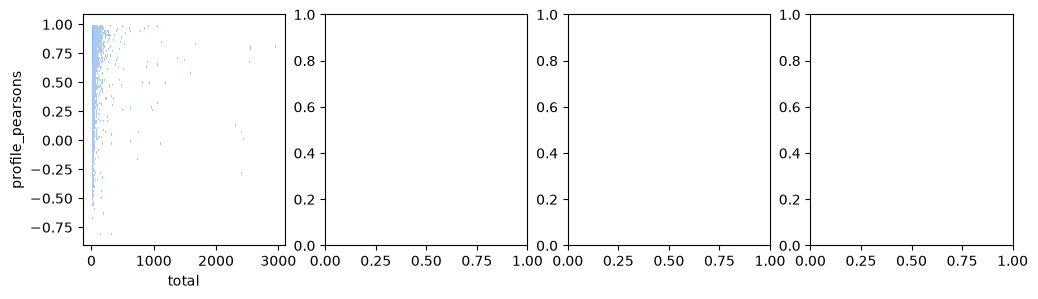

In [ ]:
# f, axes = plt.subplots(1,4, figsize = (12,3))
# sns.histplot(data = test_metrics,x='total', y='profile_pearsons', ax = axes[0])
# sns.regplot(data = test_metrics,x='total', y='profile_pearsons', scatter = False, ax = axes[0],lowess=True)
# axes[0].set_xlim(0,1000)

# sns.histplot(data = test_metrics, x='dlogodds', y='dlogodds_pred', ax = axes[1])

# sns.histplot(data = test_metrics, x='dlogodds', y='pi', ax = axes[2])

# sns.histplot(data =test_metrics, x='total', y='dlogodds', ax = axes[3])
# sns.regplot(data =test_metrics, x='total', y='dlogodds', scatter = False, ax = axes[3],lowess=True)
# axes[3].set_xscale('log')
# sns.despine()

In [ ]:
# download checkpoints
!zip -r log.zip log/
from google.colab import files
files.download("log.zip")

updating: log/ (stored 0%)
updating: log/metrics.csv (deflated 73%)
updating: log/checkpoints/ (stored 0%)
updating: log/checkpoints/epoch=2-step=4986.ckpt (deflated 16%)
updating: log/checkpoints/epoch=4-step=8310.ckpt (deflated 16%)
updating: log/checkpoints/epoch=15-step=26592.ckpt (deflated 15%)
updating: log/checkpoints/epoch=3-step=6648.ckpt (deflated 16%)
updating: log/checkpoints/epoch=5-step=9972.ckpt (deflated 16%)
updating: log/checkpoints/epoch=18-step=31578.ckpt (deflated 16%)
updating: log/checkpoints/epoch=13-step=23268.ckpt (deflated 15%)
updating: log/checkpoints/epoch=12-step=21606.ckpt (deflated 15%)
updating: log/checkpoints/epoch=19-step=33240.ckpt (deflated 16%)
updating: log/checkpoints/epoch=1-step=3324.ckpt (deflated 17%)
  adding: log/checkpoints/epoch=15-step=26592-v1.ckpt (deflated 15%)
  adding: log/checkpoints/epoch=19-step=33240-v1.ckpt (deflated 16%)
  adding: log/checkpoints/epoch=18-step=31578-v1.ckpt (deflated 16%)
  adding: log/checkpoints/epoch=10-s

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# from huggingface_hub import create_repo

# create_repo(
#     "yeolab/RBPNet",
#     repo_type="model"
# )